# CATS vs DOGS 이진 분류

In [1]:
# tensorflow 버전 확인
import tensorflow as tf

tf.__version__

'2.12.0'

In [1]:
# 내 구글 드라이버에 연동
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# dataset 다운로드
from urllib.request import urlretrieve

urlretrieve('http://doc.mindscale.kr/km/unstructured/dog-vs-cat.zip','dog-vs-cat.zip')

# 압축파일 해제
from zipfile import ZipFile

with ZipFile('dog-vs-cat.zip') as z:
    z.extractall()

In [4]:
# 구글 드라이버 확인
!ls

dog-vs-cat  dog-vs-cat.zip  gdrive  sample_data


In [5]:
# dataset을 내 구글 드라이버로 이동시킴
!mv dog-vs-cat '/content/gdrive/My Drive/CV/Cats vs Dogs/'

mv: inter-device move failed: 'dog-vs-cat' to '/content/gdrive/My Drive/CV/Cats vs Dogs/dog-vs-cat'; unable to remove target: Directory not empty


In [6]:
# 다운로드 받았던 파일 제거
!rm dog-vs-cat.zip

In [2]:
# 구글 드라이버로 이동된 dataset 확인
!ls '/content/gdrive/My Drive/CV/Cats vs Dogs/dog-vs-cat/'

train  validation


In [3]:
# 필요한 패키지와 모듈을 불러옴
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# 하이퍼파라미터 설정
image_height = 150   # 이미지 높이
image_width = 150    # 이미지 넓이
batch_size = 10      # batch size
no_of_epochs  = 50   # training 횟수

In [5]:
# ImageDataGenerator 클래스를 통해 train_datagen 인스턴스를 만듭니다.
train_datagen = ImageDataGenerator(
        rescale=1./255,         # 픽셀 값을 0~1 범위로 변환
        rotation_range=40,      # 40도까지 회전
        width_shift_range=0.2,  # 20%까지 좌우 이동
        height_shift_range=0.2, # 20%까지 상하 이동
        shear_range=0.2,        # 20%까지 기울임
        zoom_range=0.2,         # 20%까지 확대
        horizontal_flip=True,   # 좌우 뒤집기
    )

In [6]:
# train_datagen 인스턴스를 통해 train dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 train_generator 객체를 생성한다.

# flow_from_directory() : directory 경로로부터 데이터프레임을 가져오고 augmented 또는 normalized된 데이터 배치를 생성한다.
# flow_from_directory()는 이름에서도 알 수 있다시피 어떤 디렉토리와 관련된 함수라는 것을 알 수 있다.
#   - 여기서 어떤 디렉토리란 무엇일까? 바로 메타 데이터가 담긴 디렉토리를 의미한다.

train_generator = train_datagen.flow_from_directory('gdrive/My Drive/CV/Cats vs Dogs/dog-vs-cat/train',
    batch_size=10,       # Size of the batches of data (default: 32).
    class_mode='binary', # Determines the type of label arrays that are returned.
                         # "categorical" will be 2D one-hot encoded labels, "binary" will be 1D binary labels, "sparse" will be 1D integer labels
    target_size=(image_width, image_height)) # 이미지의 크기 재정의

Found 2000 images belonging to 2 classes.


In [7]:
# ImageDataGenerator를 통해 validation dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 test_generator 객체를 생성한다.
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'gdrive/My Drive/CV/Cats vs Dogs/dog-vs-cat/validation',
    batch_size=10,
    class_mode='binary',
    target_size=(image_width, image_height))

Found 800 images belonging to 2 classes.


In [8]:
# ImageDataGenerator를 통해 validation dataset 에서 한번에 batch_size 만큼 이미지를 만들어내는 pred_generator 객체를 생성한다.
pred_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'gdrive/My Drive/CV/Cats vs Dogs/dog-vs-cat/validation',
    batch_size=1,
    class_mode='binary',
    target_size=(image_width, image_height))

Found 800 images belonging to 2 classes.


In [9]:
# train_generator 가 만들어 내는 이미지의 클래스 인덱스가 무엇인지 확인해 본다.

print(train_generator.class_indices)

{'cat': 0, 'dog': 1}


In [10]:
# label name 을 찾아 오는 함수를 정의한다.
def findKey(indices, search_value):
    for key, value in indices.items():
        if(value == search_value):
            return key
    return -1

In [11]:
# train dataset 에서 샘플 데이터를 display 해본다.
for X_batch, y_batch in ImageDataGenerator(rescale=1./255).flow_from_directory('gdrive/My Drive/CV/Cats vs Dogs/dog-vs-cat/train',
                                                                                batch_size=16, class_mode='binary', target_size=(150, 150)):
    plt.figure(figsize=(20,20))
    # create a grid of 4x4 images
    for i in range(0, 16):
        ax = plt.subplot(4, 4, i+1)
        ax.set_title(findKey(train_generator.class_indices, y_batch[i]))   # 이미지의 label name 을 찾아온다
        plt.imshow((X_batch[i].reshape(150, 150, 3)*255).astype(np.uint8)) # train 샘플 이미지를 보여준다.
    # show the plot
    plt.show()
    break

Output hidden; open in https://colab.research.google.com to view.

In [12]:
# create model(모델을 만듭니다)
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_height,image_width, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer=RMSprop(lr=1e-4), metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

In [13]:
# 모델 학습시 정확도를 모니터링하여 조기에 학습을 종료시키는 인스턴스 정의

# Tensorflow, 케라스 콜백함수 EarlyStopping() :
#  - 모델을 더 이상 학습을 못할 경우(loss, metric등의 개선이 없을 경우), 학습 도중 미리 학습을 종료시키는 콜백함수이다.

monitor_val_acc = EarlyStopping(monitor='val_accuracy', patience=5)

In [14]:
# model training(모델을 학습시킵니다)
history = model.fit_generator(generator=train_generator,
                    steps_per_epoch=2000//batch_size,
                    epochs=no_of_epochs,
                    validation_data=test_generator,
                    validation_steps=800//batch_size,
                    callbacks=[monitor_val_acc])
# 정확도를 모니터링하다가 증가되지 않고 떨어지거나 변화가 거의 없다면 patience 만큼 기다리다 학습을 중단함

<ipython-input-14-0b4aa1b5b217>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(generator=train_generator,


Epoch 1/50
200/200 [==============================] - 644s 3s/step - loss: 0.7035 - accuracy: 0.5220 - val_loss: 0.6718 - val_accuracy: 0.5863
Epoch 2/50
200/200 [==============================] - 140s 697ms/step - loss: 0.6842 - accuracy: 0.5665 - val_loss: 0.6604 - val_accuracy: 0.6237
Epoch 3/50
200/200 [==============================] - 134s 670ms/step - loss: 0.6768 - accuracy: 0.5695 - val_loss: 0.6689 - val_accuracy: 0.6112
Epoch 4/50
200/200 [==============================] - 143s 718ms/step - loss: 0.6625 - accuracy: 0.6140 - val_loss: 0.6501 - val_accuracy: 0.6100
Epoch 5/50
200/200 [==============================] - 132s 659ms/step - loss: 0.6623 - accuracy: 0.6190 - val_loss: 0.6139 - val_accuracy: 0.6687
Epoch 6/50
200/200 [==============================] - 138s 690ms/step - loss: 0.6614 - accuracy: 0.6250 - val_loss: 0.7158 - val_accuracy: 0.5537
Epoch 7/50
200/200 [==============================] - 136s 681ms/step - loss: 0.6612 - accuracy: 0.6370 - val_loss: 0.5962 - va

In [ ]:
# model evaluate(모델을 평가해 봅니다)
score = model.evaluate(test_generator, steps=800//batch_size, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1]*100)

Test loss: 0.5526673793792725
Test accuracy: 70.99999785423279


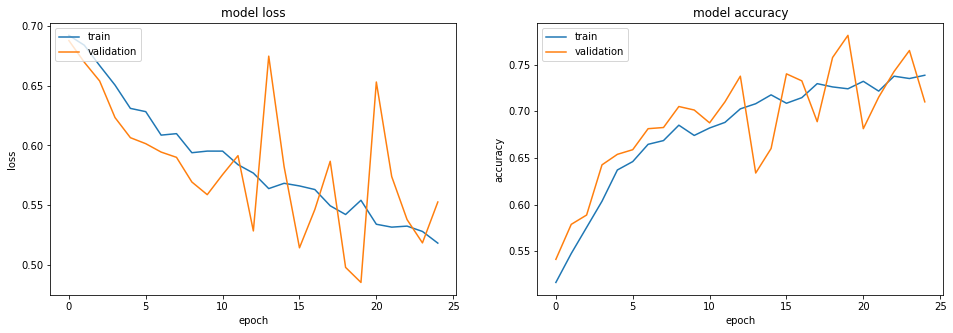

In [ ]:
plt.figure(figsize=(16,5))

# 만들어진 모델에 대해 train dataset과 validation dataset의 loss 를 그래프로 표현해 봅니다.
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

# 만들어진 모델에 대해 train dataset과 validation dataset의 accuracy 를 그래프로 표현해 봅니다.
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')

In [ ]:
# 전체 모델을 H5 파일로 저장합니다.
model.save('Cats_vs_Dogs_model.h5')
print("Saved model to disk")

Saved model to disk


In [ ]:
# 전체 학습된 모델을 H5파일로 저장하고, 그 파일을 내 구글 드라이버로 이동시킴
!mv Cats_vs_Dogs_model.h5 /content/gdrive/My\ Drive/CV/Cats\ vs\ Dogs/

In [ ]:
# pred_generator 가 만들어낸 이미지를 우리가 만든 모델을 통해 분류 예측해 봅니다.
predictions = model.predict(pred_generator, steps=16, verbose=1)

16/16 [==============================] - 0s 21ms/step


In [ ]:
# predictions shape 확인
predictions.shape

(16, 1)

In [ ]:
# 예측결과 확인
predictions

array([[0.1696523 ],
       [0.3645607 ],
       [0.07953901],
       [0.53780824],
       [0.6138283 ],
       [0.06508067],
       [0.02131473],
       [0.9830064 ],
       [0.50652534],
       [0.7645795 ],
       [0.98972636],
       [0.38176018],
       [0.34120196],
       [0.4365621 ],
       [0.13959974],
       [0.99547064]], dtype=float32)

In [ ]:
# pred_generator 가 만들어 내는 이미지의 클래스 인덱스가 무엇인지 확인해 본다.
print(pred_generator.class_indices)

{'cat': 0, 'dog': 1}


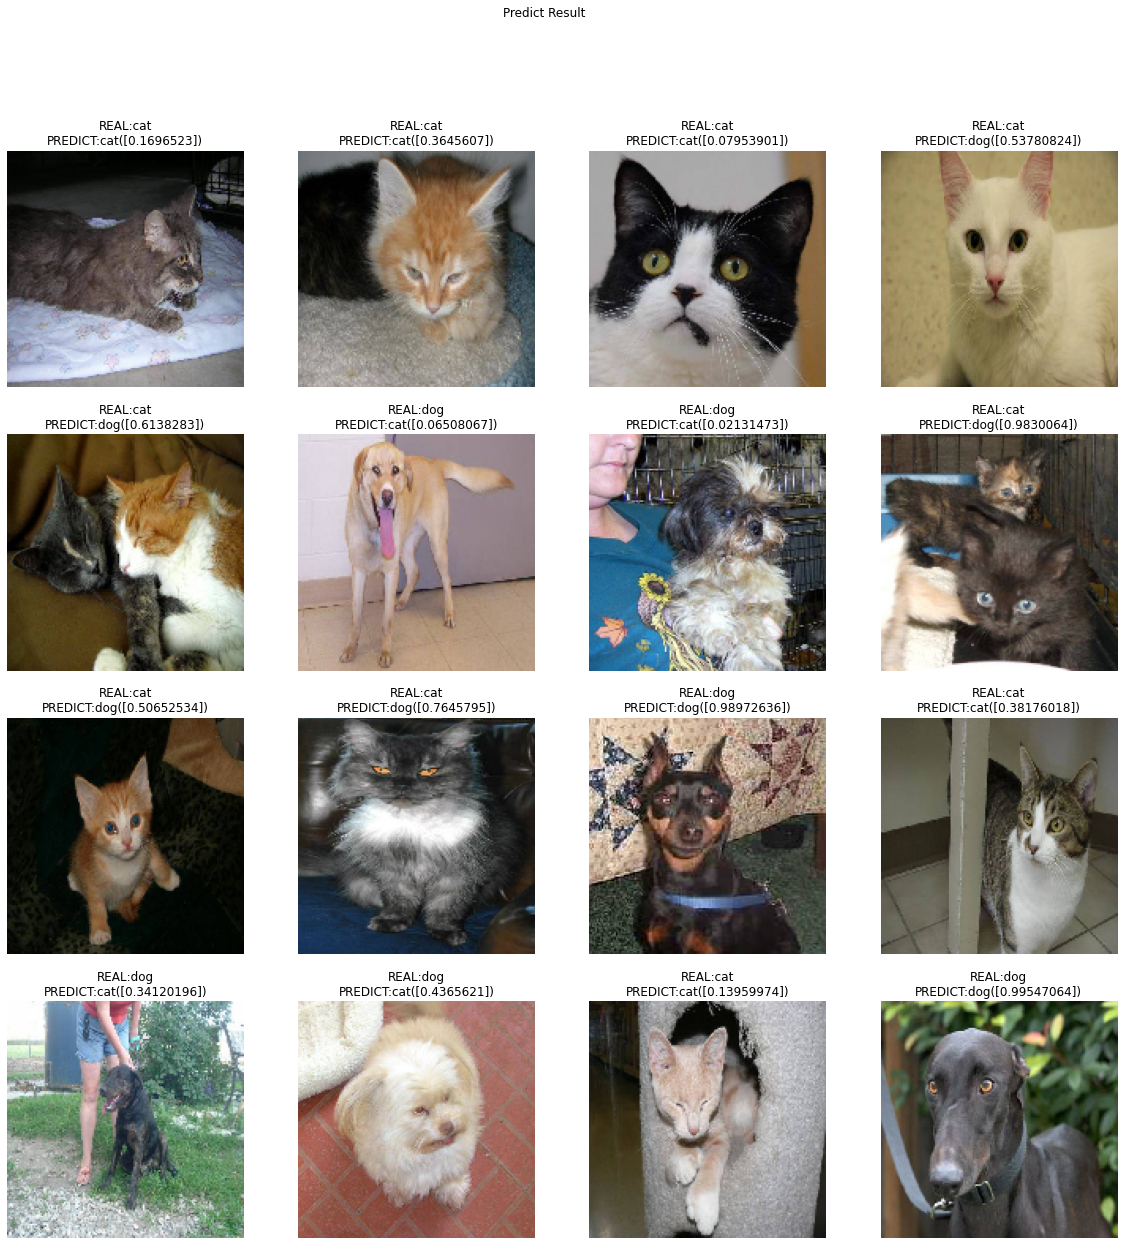

In [ ]:
# Predict Result(pred_generator 가 만들어 낸 이미지를 우리가 만든 모델을 통해 예측한 결과를 보여줍니다.)
f,ax = plt.subplots(4,4,figsize=(20,20))

for i in range(len(predictions)):
    image, label = pred_generator.next()               # pred_generator 가 만들어 낸 이미지를 하나씩 꺼내온다
    real_class = 'cat' if int(label) == 0 else 'dog'   # pred_generator 가 만들어 낸 이미지의 label name 을 가져옴
    ax[i//4,i%4].imshow(image[0])                      # pred_generator 가 만들어 낸 이미지를 보여줌
    ax[i//4,i%4].axis('off')

    pred_class = 'dog' if predictions[i] > 0.5 else 'cat' # pred_generator 가 만들어 낸 이미지를 모델을 통해 예측한 결과 값의 label name
    pred_prob = predictions[i]                            # pred_generator 가 만들어 낸 이미지를 모델을 통해 예측한 결과(확률값)
    ax[i//4,i%4].set_title('REAL:' + real_class + '\nPREDICT:' + pred_class + '(' + str(pred_prob) + ')')  # title 에 실제값과 모델에 의해 예측된 예측값을 함께 보여준다.

f.suptitle('Predict Result')

plt.show()

# [실습] 모델을 성능을 개선해 보자.

In [ ]:
# 필요한 패키지와 모듈을 불러옴
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# create model(모델을 만듭니다)
model2 = Sequential()
model2.add(Conv2D(32, (3, 3), activation='relu', input_shape=(image_height,image_width, 3)))
model2.add(MaxPooling2D((2, 2)))
model2.add(Conv2D(64, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))
model2.add(Conv2D(128, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))
model2.add(Conv2D(128, (3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))
model2.add(Flatten())
model2.add(Dropout(0.5))
model2.add(Dense(512, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))
# model2.compile(loss='binary_crossentropy', optimizer=RMSprop(lr=1e-4), metrics=['accuracy'])
model2.compile(loss='binary_crossentropy', optimizer=Adam(lr=1e-3), metrics=['accuracy'])
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 17, 17, 128)      0

/usr/local/lib/python3.8/dist-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [ ]:
# Callaback 설정

# Tensorflow, 케라스 콜백함수 ReduceLROnPlateau() :
#  - 모델의 개선이 없을 경우, Learning Rate를 조절해 모델의 개선을 유도하는 콜백함수이다.

rlr_call = ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.1, patience=5, verbose=1)

In [ ]:
# 모델 학습시 정확도를 모니터링하여 조기에 학습을 종료시키는 인스턴스 정의

# Tensorflow, 케라스 콜백함수 EarlyStopping() :
#  - 모델을 더 이상 학습을 못할 경우(loss, metric등의 개선이 없을 경우), 학습 도중 미리 학습을 종료시키는 콜백함수이다.

es_call = EarlyStopping(monitor='val_accuracy', patience=5)

In [ ]:
# model training(모델을 학습시킵니다)
history = model2.fit_generator(generator=train_generator,
                    steps_per_epoch=2000//batch_size,
                    epochs=no_of_epochs,
                    validation_data=test_generator,
                    validation_steps=800//batch_size,
                    callbacks=[rlr_call, es_call])
# 정확도를 모니터링하다가 증가되지 않고 떨어지거나 변화가 거의 없다면 patience 만큼 기다리다 학습을 중단함

<ipython-input-15-7fadc6c27935>:2: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model2.fit_generator(generator=train_generator,


Epoch 1/50
200/200 [==============================] - 1287s 6s/step - loss: 0.6974 - accuracy: 0.5065 - val_loss: 0.6872 - val_accuracy: 0.5113 - lr: 0.0010
Epoch 2/50
200/200 [==============================] - 22s 108ms/step - loss: 0.6940 - accuracy: 0.5155 - val_loss: 0.6891 - val_accuracy: 0.5312 - lr: 0.0010
Epoch 3/50
200/200 [==============================] - 23s 115ms/step - loss: 0.6938 - accuracy: 0.5100 - val_loss: 0.6847 - val_accuracy: 0.5213 - lr: 0.0010
Epoch 4/50
200/200 [==============================] - 22s 108ms/step - loss: 0.6919 - accuracy: 0.5245 - val_loss: 0.6870 - val_accuracy: 0.5350 - lr: 0.0010
Epoch 5/50
200/200 [==============================] - 21s 105ms/step - loss: 0.6934 - accuracy: 0.5120 - val_loss: 0.6930 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 6/50
200/200 [==============================] - 21s 105ms/step - loss: 0.6929 - accuracy: 0.5125 - val_loss: 0.6936 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 7/50
200/200 [==============================] -